# Assignment 2

### Process
Started with a 64/64/1 network and 200 epochs and tried some variations with more and less cells/layers/epochs.  
Also increased batch size to 64 since there is a lot more data in the large version.  
Early stopping needed high patience since the model is quite unstable. Ended up dropping it in the final model. 
Too heavy regularization seemed to make the model very unstable.  
Tried combinations of L2 regularization, Dropout and Batch normalization, ended up with batch normalization and low dropout for good results.
Below is training the initial model with the validation split and at the very bottom there is the final training with training+validation data used for training.
Ended up with MAE of 0.3358 on the test set.


In [60]:
import matplotlib.pyplot as plt
import numpy as np
from keras.regularizers import l2
from keras.models import Sequential
from keras.layers import Input, Dense, BatchNormalization, Dropout
from keras.datasets import california_housing
from keras.callbacks import EarlyStopping

(inputs, targets), (x_test, y_test) = california_housing.load_data(version='large', 
                                        test_split=0.2)
print(inputs.shape, targets.shape)
print(x_test.shape, y_test.shape)

(16512, 8) (16512,)
(4128, 8) (4128,)


In [61]:
#split validation set
x_train = inputs[:13212]
y_train = targets[:13212]
x_val = inputs[13212:]
y_val = targets[13212:]

In [62]:
#standardize
mean = x_train.mean(axis=0)
std = x_train.std(axis=0)
x_train -= mean
x_train /= std
x_test -= mean
x_test /= std
x_val -= mean
x_val /= std
y_train /= 1e5
y_test /= 1e5
y_val /= 1e5

# Training with validation split

In [143]:
model = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(1)
    ])
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

early_stop = EarlyStopping(monitor='val_loss', patience=40)
# callbacks=[early_stop],
history = model.fit(x_train, y_train, epochs=400, batch_size=64, validation_data=(x_val, y_val),  verbose=0)

Text(0, 0.5, 'Loss')

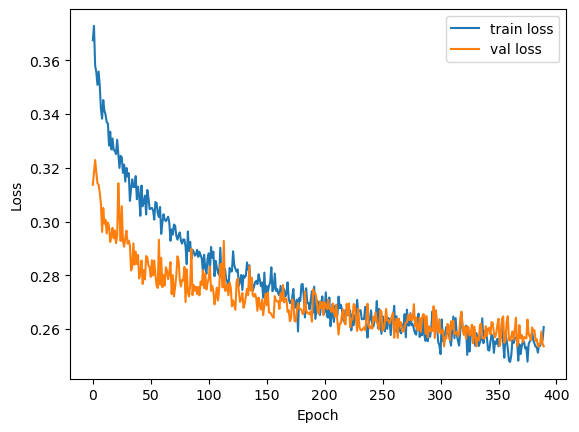

In [144]:
plt.plot(history.history['loss'][10:], label='train loss')
plt.plot(history.history['val_loss'][10:], label='val loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Loss')

Text(0, 0.5, 'Mean absolute error (in 100000 $)')

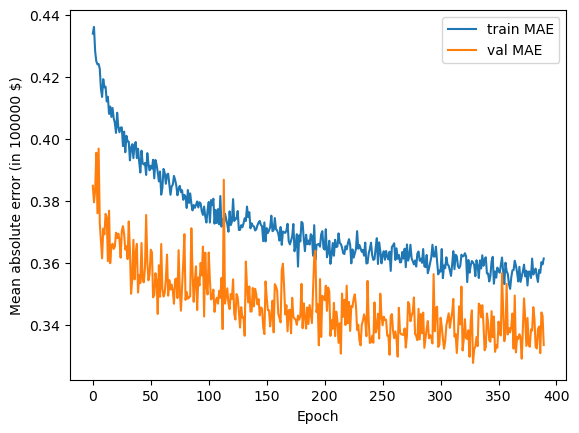

In [145]:
plt.plot(history.history['mae'][10:], label='train MAE')
plt.plot(history.history['val_mae'][10:], label='val MAE')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('Mean absolute error (in 100000 $)')

In [146]:
test_loss, test_mae = model.evaluate(x_val, y_val)
print(f'Validation mean absolute error: {test_mae:.4f}')

104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.2536 - mae: 0.3335
Validation mean absolute error: 0.3335


# Final training

In [148]:
x_train_full = np.concatenate((x_train, x_val), axis=0) # join train + val sets
y_train_full = np.concatenate((y_train, y_val), axis=0)
model_full = Sequential([
    Input(shape=(8,)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.1),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dense(1)
    ])
model_full.compile(optimizer='adam',loss='mse',metrics=['mae'])

history = model_full.fit(x_train_full, y_train_full, epochs=400, batch_size=64,  verbose=0)

In [151]:
test_loss, test_mae = model_full.evaluate(x_test, y_test)
print(f'Test mean absolute error: {test_mae:.4f}')

129/129 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.2569 - mae: 0.3358
Test mean absolute error: 0.3358


In [152]:
from keras.losses import MeanAbsoluteError

y_pred_baseline = np.full_like(y_test, np.mean(y_train_full, axis=0))
mae_fn = MeanAbsoluteError()
mae_baseline = mae_fn(y_test, y_pred_baseline).numpy()
print(f'Mean baseline MAE: {mae_baseline:.4f}')

Mean baseline MAE: 0.9059
